## Analyse des résultats

In [2]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

resultats_qwen2.5-7b-instruct


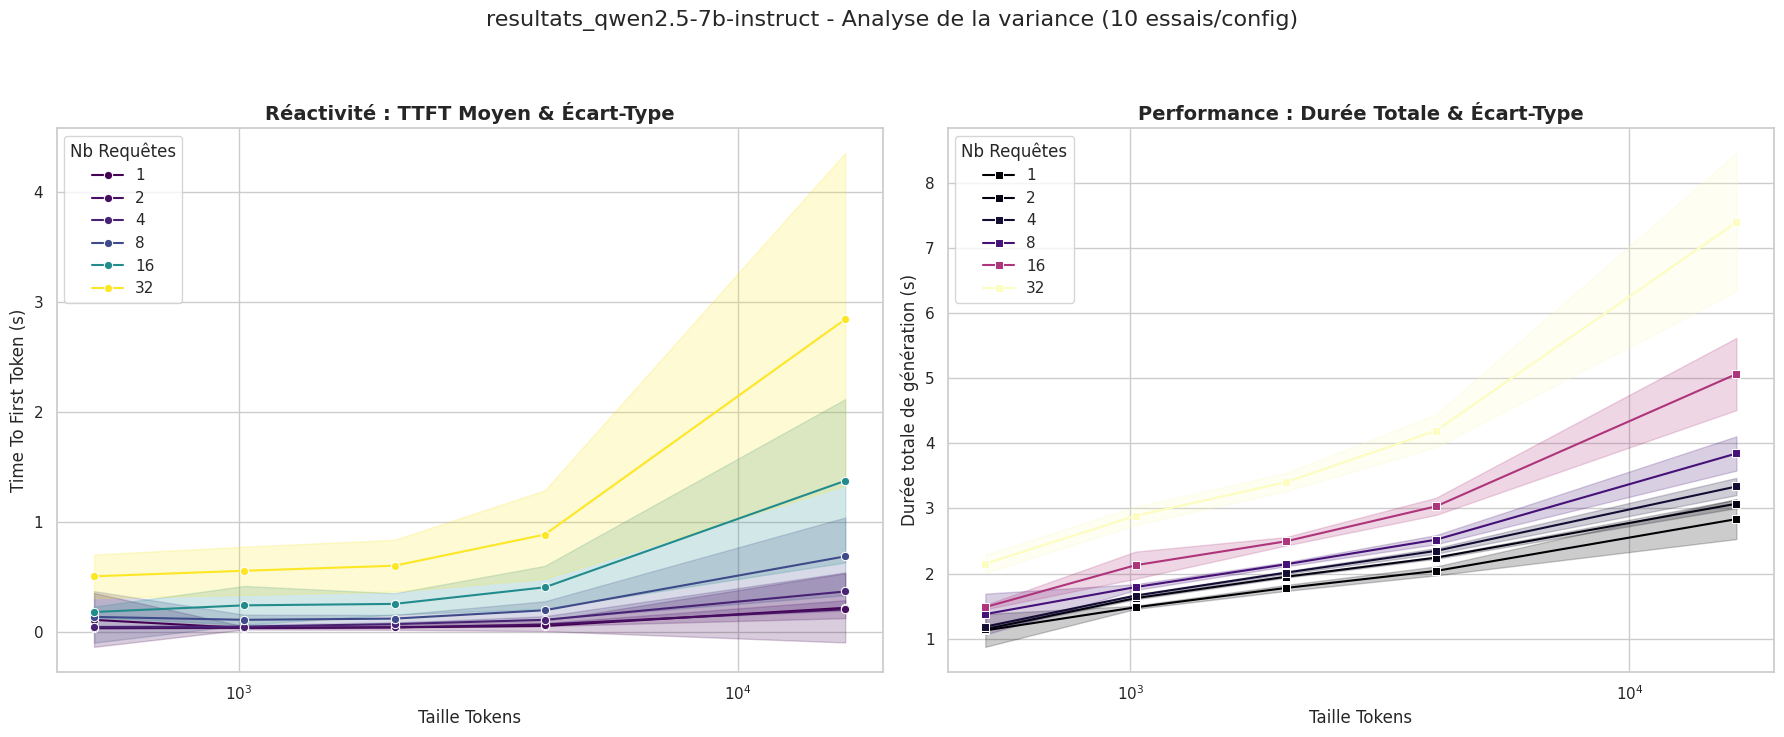

In [ ]:
# 1. Chargement des données (Format Liste)
try:
    with open("./resultats_tests/resultats_Qwen2.5-7B-Instruct.json", "r") as f:
        data = json.load(f)
        nom = f.name
        nom = nom.split("/")[-1]
        nom = nom.rsplit(".", 1)[0].lower()
        print(nom)
except FileNotFoundError:
    print("Erreur : Le fichier est introuvable.")
    exit()

# 2. Conversion directe en DataFrame
# Comme ton JSON est déjà une liste d'objets avec les bonnes clés,
# on peut le charger directement sans boucle for.
df = pd.DataFrame(data)

# Renommage pour l'affichage des graphiques
df = df.rename(
    columns={
        "nb_requetes_simultanees": "Nb Requêtes",
        "taille_tokens": "Taille Tokens",
        "duree": "Durée (s)",
        "ttft": "TTFT (s)",
        "essai_index": "Essai ID",
    }
)

# 3. Configuration Graphique
sns.set_theme(style="whitegrid", palette="muted")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Graphique 1 : TTFT avec Écart-Type ---
sns.lineplot(
    data=df,
    x="Taille Tokens",
    y="TTFT (s)",
    hue="Nb Requêtes",
    marker="o",
    errorbar="sd",  # Affiche l'écart-type sous forme de zone ombrée
    palette="viridis",
    ax=ax1,
)
ax1.set_title("Réactivité : TTFT Moyen & Écart-Type", fontsize=14, fontweight="bold")
ax1.set_xscale("log", base=10)
ax1.set_ylabel("Time To First Token (s)")

# --- Graphique 2 : Durée Totale avec Écart-Type ---
sns.lineplot(
    data=df,
    x="Taille Tokens",
    y="Durée (s)",
    hue="Nb Requêtes",
    marker="s",
    errorbar="sd",  # Calcule et affiche l'écart-type automatiquement
    palette="magma",
    ax=ax2,
)
ax2.set_title("Performance : Durée Totale & Écart-Type", fontsize=14, fontweight="bold")
ax2.set_xscale("log", base=10)
ax2.set_ylabel("Durée totale de génération (s)")

# Titre général
nb_essais = df["Essai ID"].max() + 1
plt.suptitle(
    f"{nom} - Analyse de la variance ({nb_essais} essais/config)",
    fontsize=16,
    y=1.05,
)

plt.tight_layout()
plt.savefig(f"./resultats_tests/{nom}.png", dpi=300, bbox_inches="tight")
plt.show()